In [1]:
import os, math
import time
import multiprocessing as multipr
from concurrent.futures import ProcessPoolExecutor
from typing import Optional, Tuple
import matplotlib.pyplot as plt

import numpy as np
from scipy.integrate import quad
from scipy.optimize import minimize, minimize_scalar
import scipy.stats as st
from scipy.stats import norm
from scipy.special import beta as beta_fn, roots_jacobi
import warnings
import mpmath as mp
mp.mp.dps = 50

In [2]:


# -------------------- worker helpers (top-level & picklable) --------------------
def _init_worker():
    # prevent BLAS oversubscription inside workers
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")


In [3]:

def tukey_gh_sample(n, mu=0.0, sigma=0.0, g=0.0, h=0.0, random_state=None, Z=None):
    """
    Sample from the Tukey g-and-h distribution.
    
    Parameters
    ----------
    n : int
        Number of samples.
    mu : float
        Location parameter.
    sigma : float
        Scale parameter.
    g : float
        Skewness parameter.
    h : float
        Tail heaviness parameter.
    random_state : int or None
        Seed for reproducibility.
        
    Returns
    -------
    x : np.ndarray, shape (n,)
        Samples from the g-and-h distribution.
    """
    rng = np.random.default_rng(random_state)
    if Z is None:
        Z = rng.standard_normal(n)
    
    if g != 0:
        Y = (np.exp(g * Z) - 1) / g
    else:
        Y = Z
    X = mu + sigma * Y * np.exp(h * Z**2 / 2)
    return X


import numpy as np

def tukey_gh_sample_with_grads(n, mu=0.0, sigma=0.0, g=0.0, h=0.0, random_state=None, Z=None):
    """
    Sample from the Tukey g-and-h distribution and return gradients of the
    samples w.r.t. parameters (mu, sigma, g, h).
    """
    rng = np.random.default_rng(random_state)
    if Z is None:
        Z = rng.standard_normal(n)

    # Compute Y and dY/dg
    if g != 0:
        Y = (np.exp(g * Z) - 1) / g
        dY_dg = (g * Z * np.exp(g * Z) - (np.exp(g * Z) - 1)) / (g**2)
    else:
        Y = Z
        dY_dg = 0.5 * Z**2  # limit as g->0
    exp_h = np.exp(h * Z**2 / 2.0)

    X = mu + sigma * Y * exp_h

    # Gradients
    dX_dmu = np.ones_like(Z)
    dX_dsigma = Y * exp_h
    dX_dg = sigma * dY_dg * exp_h
    dX_dh = sigma * Y * (Z**2 / 2.0) * exp_h

    # grads = {
    #     "mu": dX_dmu,
    #     "sigma": dX_dsigma,
    #     "g": dX_dg,
    #     "h": dX_dh,
    # }
    grads = np.array([dX_dmu,dX_dsigma,dX_dg,dX_dh])

    return X, grads





In [4]:

def tukey_gh_ppf(p, mu=0.0, sigma=1.0, g=0.0, h=0.0):
    """Quantile function Q(p) of Tukey g-and-h."""
    z = norm.ppf(p)
    if g != 0.0:
        y = (np.exp(g * z) - 1.0) / g
    else:
        y = z
    return mu + sigma * y * np.exp(0.5 * h * z**2)


def tukey_gh_pdf(x, mu=0.0, sigma=1.0, g=0.0, h=0.0):
    """Numerical PDF of Tukey g-and-h using change of variables."""
    # Find corresponding z via inverse transformation
    # We solve Q(p) = x, where z = Phi^{-1}(p).
    # Equivalent: x = mu + sigma * T(z)
    # So we can map x back to z numerically.
    # But easier: compute density directly via dQ/dz and normal density.

    # z -> transformation
    def t(z):
        if g != 0:
            return (np.exp(g * z) - 1) / g * np.exp(0.5 * h * z**2)
        else:
            return z * np.exp(0.5 * h * z**2)

    def dt_dz(z):
        if g != 0:
            term1 = np.exp(g*z) * np.exp(0.5*h*z**2)
            term2 = ((np.exp(g*z)-1)/g) * (h*z*np.exp(0.5*h*z**2))
            return term1 + term2
        else:
            return np.exp(0.5*h*z**2) * (1 + h*z**2)

    # Map z -> x
    # z = st.norm.ppf(st.norm.cdf((x-mu)/sigma))  # initial guess: not exact
    # Actually easier: just invert using z grid
    z_grid = np.linspace(-6,6,20001)
    x_grid = mu + sigma * t(z_grid)
    pdf_vals = st.norm.pdf(z_grid) / (sigma * dt_dz(z_grid))

    # Interpolate
    return np.interp(x, x_grid, pdf_vals)


# E[exp(a Z + b Z^2)] for Z~N(0,1), valid for 2b < 1
# = (1 - 2b)^(-1/2) * exp( a^2 / (2(1 - 2b)) )
def _E_exp_aZ_bZ2(a, b):
    # assume float64; user ensures 2b < 1
    s = 1.0 - 2.0*b
    return s**(-0.5) * np.exp( (a*a) / (2.0*s) )

def _expm1_over_x(x):
    # stable (exp(x)-1)/x, with x→0 -> 1
    out = np.ones_like(x, dtype=float)
    mask = np.abs(x) > 1e-12
    out[mask] = np.expm1(x[mask]) / x[mask]
    return out

def tukey_gh_moments_stable(mu=0.0, sigma=1.0, g=0.0, h=0.0):
    """
    Returns (E[t], E[t^2]) for t(Z) = ((exp(gZ)-1)/g) * exp(0.5*h*Z^2), Z~N(0,1).
    Stable for small |g| and h near 0 (but requires h<1 for E[t], h<1/2 for E[t^2]).
    """
    g = float(g)
    h = float(h)

    if h >= 1.0 - 1e-15:
        raise ValueError("E[t] diverges for h >= 1.")
    if h >= 0.5 - 1e-15:
        # E[t^2] diverges at/above 1/2; we still can compute E[t] if needed.
        # We'll return np.inf for E[t^2].
        second_diverges = True
    else:
        second_diverges = False

    # ---- E[t] ----
    # E[t] = ( E[exp(gZ + (h/2)Z^2)] - E[exp((h/2)Z^2)] ) / g
    # Let s1 = 1-h, x1 = g^2/(2*s1)
    s1 = 1.0 - h
    x1 = (g*g) / (2.0 * s1)
    pref1 = s1**(-0.5)                      # 1/sqrt(1-h)
    # Use expm1 to avoid cancellation when x1 small
    if np.abs(g) < 1e-12:
        E_t = 0.0  # exact odd moment limit as g->0
    else:
        E_t = pref1 * np.expm1(x1) / g

    # ---- E[t^2] ----
    if second_diverges:
        E_t2 = np.inf
    else:
        # E[t^2] = ( E[exp(2gZ + hZ^2)] - 2 E[exp(gZ + hZ^2)] + E[exp(hZ^2)] ) / g^2
        # Let s2 = 1 - 2h, x = g^2 / (2*s2).
        s2 = 1.0 - 2.0*h
        x = (g*g) / (2.0 * s2)
        pref2 = s2**(-0.5)                  # 1/sqrt(1-2h)
        if np.abs(g) < 1e-12:
            # limit g->0: E[Z^2 exp(h Z^2)] = (1-2h)^(-3/2)
            E_t2 = s2**(-1.5)
        else:
            # Compute expr = exp(4x) - 2 exp(x) + 1 in a stable way:
            # factor by max exponent to avoid overflow
            m = max(4.0*x, x, 0.0)
            expr = np.exp(4.0*x - m) - 2.0*np.exp(x - m) + np.exp(-m)
            E_t2 = pref2 * np.exp(m) * (expr / (g*g))

    m1_t = mu + sigma * E_t
    m2_t = mu**2 + 2*mu*sigma*E_t + sigma**2 * E_t2
    return m1_t, m2_t

In [5]:
def tukey_order_stat_moment_mp(k, N, g, h, r, mu=0.0, sigma=1.0, dps=50):
    """
    E[X_(k)^r] for Tukey g-and-h via z-integral:
    1/B * ∫ (mu+sigma*t_g,h(z))^r * Phi(z)^(k-1) * (1-Phi(z))^(N-k) * phi(z) dz
    Valid if h < 1/r.
    """
    if h >= 1.0 / r:
        raise ValueError(f"{r}-th moment does not exist for h >= {1.0/r}")
    mp.mp.dps = dps

    sqrt2 = mp.sqrt(2)
    inv_sqrt2pi = 1.0/mp.sqrt(2*mp.pi)

    def Phi(z):
        return 0.5 * (1 + mp.erf(z / sqrt2))

    def phi(z):
        return inv_sqrt2pi * mp.e**(-0.5*z*z)

    def t_gh(z):
        if g != 0:
            return ((mp.e**(g*z) - 1.0)/g) * mp.e**(0.5*h*z*z)
        else:
            return z * mp.e**(0.5*h*z*z)

    B = mp.beta(k, N+1-k)

    def integrand(z):
        p = Phi(z)
        # Stable weight: exp((k-1)log p + (N-k)log(1-p))
        # Guard p in (0,1) numerically:
        if p <= 0: 
            return mp.mpf('0')
        if p >= 1:
            return mp.mpf('0')
        logw = (k-1)*mp.log(p) + (N-k)*mp.log1p(-p)   # log(1-p) stable
        x = mu + sigma * t_gh(z)
        return (x**r) * mp.e**(logw) * phi(z)

    val = mp.quad(integrand, [-mp.inf, mp.inf])
    return float(val / B)




def tukey_order_stat_moment_sc(k, N, g=0.0, h=0.0, r=1, mu=0.0, sigma=1.0, nquad=200):
    """
    E[X_{(k)}^r] for Tukey g-and-h via Gauss–Jacobi quadrature.
    Conditions: 1 <= k <= N and h < 1/r (moment existence).
    """
    if not (1 <= k <= N):
        raise ValueError("k must satisfy 1 <= k <= N")
    if h >= 1.0 / r:
        raise ValueError(f"{r}-th moment does not exist for h >= {1.0/r}")

    # Jacobi nodes/weights on [-1,1] for weight (1-x)^alpha (1+x)^beta
    alpha = N - k     # power on (1-p)
    beta_ = k - 1     # power on p
    x, w = roots_jacobi(nquad, alpha, beta_)   # x in [-1,1]

    # Map to p in (0,1)
    p = (x + 1.0) / 2.0

    # Constant from change of variables:
    # ∫_0^1 p^beta (1-p)^alpha f(p) dp = 2^{-(alpha+beta+1)} * Σ w_i f(p_i)
    const = 2.0 ** (-(alpha + beta_ + 1.0))

    Q = tukey_gh_ppf(p, mu=mu, sigma=sigma, g=g, h=h)
    integral = const * np.dot(w, Q**r)
    return integral / beta_fn(k, N + 1 - k)

def tukey_order_stat_moment(k, N, g=0.0, h=0.0, r=1, mu=0.0, sigma=1.0, dps=50, nquad=200, ver='mp'):
    if ver == 'mp':
        return tukey_order_stat_moment_mp(k, N, g, h, r, mu=mu, sigma=sigma, dps=dps)
    return tukey_order_stat_moment_sc(k, N, g=g, h=h, r=r, mu=mu, sigma=sigma, nquad=nquad)

def tukey_cross_moment_mp(g1, h1, g2, h2, mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=1.0, dps=50):
    mp.mp.dps = dps

    sqrt2 = mp.sqrt(2)
    inv_sqrt2pi = 1.0/mp.sqrt(2*mp.pi)

    def Phi(z):
        return 0.5 * (1 + mp.erf(z / sqrt2))

    def phi(z):
        return inv_sqrt2pi * mp.e**(-0.5*z*z)

    def t_gh(z, g, h):
        if g != 0:
            return ((mp.e**(g*z) - 1.0)/g) * mp.e**(0.5*h*z*z)
        else:
            return z * mp.e**(0.5*h*z*z)

    def integrand(z):
        p = Phi(z)
        # Stable weight: exp((k-1)log p + (N-k)log(1-p))
        # Guard p in (0,1) numerically:
        if p <= 0: 
            return mp.mpf('0')
        if p >= 1:
            return mp.mpf('0')
        
        x1 = mu1 + sigma1 * t_gh(z, g1, h1)
        x2 = mu2 + sigma2 * t_gh(z, g2, h2)
        return (x1*x2) * phi(z)

    val = mp.quad(integrand, [-mp.inf, mp.inf])
    return float(val)

def _tukey_t(z, g, h, g_eps=1e-10):
    """t_{g,h}(z) with the g->0 limit handled."""
    if abs(g) < g_eps:
        return z * np.exp(0.5 * h * z * z)
    return ((np.exp(g * z) - 1.0) / g) * np.exp(0.5 * h * z * z)

def tukey_cross_moment_sc(g1, h1, g2, h2, mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=1.0, nquad=200):
    """
    E[X1 * X2] with Xj = mu_j + sigma_j * t_{gj,hj}(Z),  Z ~ N(0,1).
    Uses scipy.integrate.quad over (-inf, inf).

    Requires h1 + h2 < 1 for integrability.
    """
    if h1 + h2 >= 1.0 - 1e-14:
        raise ValueError("Integral diverges: need h1 + h2 < 1.")

    inv_sqrt2pi = 1.0 / np.sqrt(2.0 * np.pi)

    def phi(z):
        return inv_sqrt2pi * np.exp(-0.5 * z * z)

    def integrand(z):
        t1 = _tukey_t(z, g1, h1)
        t2 = _tukey_t(z, g2, h2)
        x1 = mu1 + sigma1 * t1
        x2 = mu2 + sigma2 * t2
        return (x1 * x2) * phi(z)

    # quad over (-inf, inf); increase 'limit' for tougher (g,h)
    val, err = quad(integrand, -np.inf, np.inf, epsabs=1e-9, epsrel=1e-9, limit=nquad)
    return float(val)

def tukey_cross_moment(g1, h1, g2, h2, mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=1.0, dps=50, nquad=200, ver='mp'):
    if ver == 'mp':
        return tukey_cross_moment_mp(g1, h1, g2, h2, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, dps=dps)
    return tukey_cross_moment_sc(g1, h1, g2, h2, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, nquad=nquad)

In [6]:
def _tukey_k(k, N, mu1, sigma1, g1, h1, dps, nquad, ver):
    return tukey_order_stat_moment(k, N, g1, h1, r=1, mu=mu1, sigma=sigma1, dps=dps, nquad=nquad, ver=ver)

def build_m1is_tukey(N, mu1, sigma1, g1, h1, dps=50, nquad=200, ver='mp', use_par=True, pool=None, chunksize=None):
    if not use_par:
        np.array([tukey_order_stat_moment(k+1, N, g1, h1, r=1, mu=mu1, sigma=sigma1, dps=dps, nquad=nquad, ver=ver) for k in range(N)])
    # with multipr.Pool() as pool:
    #     vals = pool.starmap(_tukey_k, [(k+1, N, mu1, sigma1, g1, h1, dps, nquad, ver) for k in range(N)])
    args = [(k+1, N, mu1, sigma1, g1, h1, dps, nquad, ver) for k in range(N)]
    if chunksize is None:
        chunksize = max(1, math.ceil(N / (4 * (multipr.cpu_count() or 1))))

    if pool is not None:
        vals = pool.starmap(_tukey_k, args, chunksize=chunksize)
        return np.array(vals)

    with multipr.Pool(initializer=_init_worker) as p:
        vals = p.starmap(_tukey_k, args, chunksize=chunksize)
    return np.array(vals)

In [7]:
def true_W_tukey(g1, h1, g2, h2, mu1=0, sigma1=1, mu2=0, sigma2=1, dps=50, nquad=200, ver='mp'):
    m1_1, m2_1 = tukey_gh_moments_stable(g=g1, h=h1, mu=mu1, sigma=sigma1)
    m1_2, m2_2 = tukey_gh_moments_stable(g=g2, h=h2, mu=mu2, sigma=sigma2)
    return m2_1 + m2_2 - 2*tukey_cross_moment(g1, h1, g2, h2, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, dps=dps, nquad=nquad, ver=ver)

def expected_W_tukey(g1, h1, g2, h2, N, mu1=0, sigma1=1, mu2=0, sigma2=1, m1is_1=None, m1is_2=None, dps=50, nquad=200, ver='mp', use_par=False, pool=None):
    if m1is_1 is None:
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    if m1is_2 is None:
        m1is_2 = build_m1is_tukey(N, mu2, sigma2, g2, h2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    m1_1, m2_1 = tukey_gh_moments_stable(g=g1, h=h1, mu=mu1, sigma=sigma1)
    m1_2, m2_2 = tukey_gh_moments_stable(g=g2, h=h2, mu=mu2, sigma=sigma2)
    return m2_1 + m2_2 - 2*np.mean(m1is_1*m1is_2)

def expected_self_W_tukey(mu, sigma, g, h, N, m1is=None, dps=50, nquad=200, ver='mp', use_par=False, pool=None):
    if m1is is None:
        m1is = build_m1is_tukey(N, mu, sigma, g, h, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    m1, m2 = tukey_gh_moments_stable(g=g, h=h, mu=mu, sigma=sigma)
    return 2*m2 - 2*np.mean(m1is**2)

def expected_self_W_tukey_grad(mu, sigma, g, h, N, idx, base_m1is=None, eps=1e-3, dps=50, nquad=200, ver='mp', use_par=False, pool=None):
    if idx in [0,1] and base_m1is is None:
        base_m1is = build_m1is_tukey(N, 0., 1., g, h, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    if idx == 0:
        distp = expected_self_W_tukey(mu+eps, sigma, g, h, N, m1is=mu+eps+sigma*base_m1is, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_self_W_tukey(mu-eps, sigma, g, h, N, m1is=mu-eps+sigma*base_m1is, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    elif idx == 1:
        distp = expected_self_W_tukey(mu, sigma+eps, g, h, N, m1is=mu+(sigma+eps)*base_m1is, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_self_W_tukey(mu, sigma-eps, g, h, N, m1is=mu+(sigma-eps)*base_m1is, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    elif idx == 2:
        distp = expected_self_W_tukey(mu, sigma, g+eps, h, N, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_self_W_tukey(mu, sigma, g-eps, h, N, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    elif idx == 3:
        distp = expected_self_W_tukey(mu, sigma, g, h+eps, N, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_self_W_tukey(mu, sigma, g, h-eps, N, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    return (distp - distm)/2/eps

def expected_self_W_tukey_grad_gh(mu, sigma, g, h, N, eps=1e-3, dps=50, nquad=200, ver='sc', use_par=False, pool=None):
    grad = np.empty(2)
    for i, idx in enumerate([2,3]):
        grad[i] = expected_self_W_tukey_grad(mu, sigma, g, h, N, idx, eps=eps, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    return grad

def expected_self_W_tukey_grad_4d(mu, sigma, g, h, N, base_m1is=None, eps=1e-3, dps=50, nquad=200, ver='sc', use_par=False, pool=None):
    if base_m1is is None:
        base_m1is = build_m1is_tukey(N, 0., 1., g, h, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    grad = np.empty(4)
    for idx in range(4):
        grad[idx] = expected_self_W_tukey_grad(mu, sigma, g, h, N, idx, base_m1is=base_m1is, eps=eps, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    return grad


In [8]:
def expected_W_tukey_grad(g1, h1, g2, h2, N, idx, mu1=0, sigma1=1, mu2=0, sigma2=1, m1is_2=None, eps=1e-3, dps=50, nquad=200, ver='mp', use_par=False, pool=None):
    if m1is_2 is None:
        m1is_2 = build_m1is_tukey(N, mu2, sigma2, g2, h2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    if idx == 0:
        distp = expected_W_tukey(g1, h1, g2, h2, N, mu1+eps, sigma1, mu2, sigma2, m1is_2=m1is_2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_W_tukey(g1, h1, g2, h2, N, mu1-eps, sigma1, mu2, sigma2, m1is_2=m1is_2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    elif idx == 1:
        distp = expected_W_tukey(g1, h1, g2, h2, N, mu1, sigma1+eps, mu2, sigma2, m1is_2=m1is_2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_W_tukey(g1, h1, g2, h2, N, mu1, sigma1-eps, mu2, sigma2, m1is_2=m1is_2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    elif idx == 2:
        distp = expected_W_tukey(g1+eps, h1, g2, h2, N, mu1, sigma1, mu2, sigma2, m1is_2=m1is_2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_W_tukey(g1-eps, h1, g2, h2, N, mu1, sigma1, mu2, sigma2, m1is_2=m1is_2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    elif idx == 3:
        distp = expected_W_tukey(g1, h1+eps, g2, h2, N, mu1, sigma1, mu2, sigma2, m1is_2=m1is_2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
        distm = expected_W_tukey(g1, h1-eps, g2, h2, N, mu1, sigma1, mu2, sigma2, m1is_2=m1is_2, dps=dps, nquad=nquad, ver=ver, use_par=use_par, pool=pool)
    return (distp - distm)/2/eps


In [9]:


def numerical_sol_expected_loss_4d(mu1: float, sigma1: float, g1: float, h1: float,
                         N:  int, alpha = 0,
                        m1is_1 = None, ver = 'mp',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, debug=False, use_par=False, pool=None, chunksize=None):

    if m1is_1 is None:
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
    
    def objective(params):
        mu2, sigma2, g2, h2 = params
        m1is_2 = build_m1is_tukey(N, mu2, sigma2, g2, h2, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        if alpha != 0:
            return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver)) \
            - alpha*float(expected_W_tukey(g2, h2, g2, h2, N, mu1=mu2, sigma1=sigma2, mu2=mu2, sigma2=sigma2, m1is_1=m1is_2, m1is_2=m1is_2, ver=ver))
        return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver))
    
    res = minimize(objective, x0=[0.0, 1.0, 0.1, 0.1], method="Nelder-Mead",
                   bounds=[(-np.inf, np.inf), (0, np.inf), (-np.inf, np.inf), (0, 0.5-eps)],
                          options={'maxiter': maxiter})  # h<0.5 for 2nd moment existence
    
    if debug:
        return res
        
    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")
    # print(res.x, res.fun)
    
    return res.x, float(res.fun)

def numerical_sol_expected_loss_2d(g1: float, h1: float,
                         N:  int, mu1, sigma1, alpha = 0,
                        m1is_1 = None, ver = 'mp',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, debug=False, use_par=False, pool=None, chunksize=None):

    if m1is_1 is None:
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
    
    def objective(params):
        g2, h2 = params
        m1is_2 = build_m1is_tukey(N, mu1, sigma1, g2, h2, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        if alpha != 0:
            return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu1, sigma2=sigma1, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver)) \
            - alpha*float(expected_W_tukey(g2, h2, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu1, sigma2=sigma1, m1is_1=m1is_2, m1is_2=m1is_2, ver=ver))
        return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu1, sigma2=sigma1, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver))
    
    res = minimize(objective, x0=[0.1, 0.1], method="Nelder-Mead",
                   bounds=[(-np.inf, np.inf), (0, 0.5-eps)],
                          options={'maxiter': maxiter})  # h<0.5 for 2nd moment existence
    
    if debug:
        return res
        
    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")
    # print(res.x, res.fun)
    
    return res.x, float(res.fun)

def numerical_sol_expected_loss_1d(g1: float, h1: float, opt_idx: int,
                         N:  int, mu1, sigma1, alpha = 0,
                        m1is_1 = None, ver = 'mp',
                         eps: float = 1e-6,
                         *,
                         xtol: float = 1e-10,
                         maxiter: int = 500, bounds=None, use_par=False, pool=None, chunksize=None):
    """
    Find a2* that minimises   expected_wasserstein_loss_affine_emp_conti(a1, a2, n).

    Parameters
    ----------
    a1, n       : parameters forwarded to expected_wasserstein_loss_affine_emp_conti
    eps         : safety margin that keeps |a2| ≤ 2‑eps
    xtol        : desired absolute accuracy on a2*
    maxiter     : maximum bracketing iterations for Brent's method

    Returns
    -------
    a2_star, f_star   (minimiser and minimum value)
    """
    if m1is_1 is None:
        m1is_1 = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        
    # convenience wrapper around the user‑supplied objective
    def _obj(params, _mu1=mu1, _sigma1=sigma1, _g1=g1, _h1=h1):
        mu2, sigma2, g2, h2 = _mu1, _sigma1, _g1, _h1
        if opt_idx == 0:
            mu2 = params
        elif opt_idx == 1:
            sigma2 = params
        elif opt_idx == 2:
            g2 = params
        elif opt_idx == 3:
            h2 = params
        m1is_2 = build_m1is_tukey(N, mu2, sigma2, g2, h2, ver=ver, use_par=use_par, pool=pool, chunksize=chunksize)
        if alpha != 0:
            return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver)) \
            - alpha * float(expected_W_tukey(g2, h2, g2, h2, N, mu1=mu2, sigma1=sigma2, mu2=mu2, sigma2=sigma2, m1is_1=m1is_2, m1is_2=m1is_2, ver=ver))
        return float(expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, m1is_1=m1is_1, m1is_2=m1is_2, ver=ver))

    if bounds is None:
        if opt_idx == 0:
            bounds = (-1e9, 1e9)
        elif opt_idx == 1:
            bounds = (0, 1e9)
        elif opt_idx == 2:
            bounds = (-2.5, 2.5)
        elif opt_idx == 3:
            bounds = (0, 0.5-eps)
    # bounded Brent search in (‑2+eps, 2‑eps)
    res = minimize_scalar(_obj,
                          bracket=None,
                          bounds=bounds,
                          method='bounded',
                          options={'xatol': xtol, 'maxiter': maxiter})

    if not res.success:
        raise RuntimeError(f"optimisation failed: {res.message}")

    return float(res.x), float(res.fun)

In [10]:
def expr_wellspecified_4d(mu1: float, sigma1: float, g1: float, h1: float, N_set, ver='sc'):
    
    param_uncorrected_set = np.empty((len(N_set), 4))
    param_corrected_a0_5 = np.empty((len(N_set), 4))

    m1is_1_set = dict()
    with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
        for i, N in enumerate(N_set):
            m1is_1_set[str(N)] = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=True, pool=pool)
            # print(N)
            param_uncorrected_set[i], _ = numerical_sol_expected_loss_4d(mu1, sigma1, g1, h1,
                                         N, alpha = 0, m1is_1 = m1is_1_set[str(N)], ver=ver, use_par=True, pool=pool)
            param_corrected_a0_5[i], _ = numerical_sol_expected_loss_4d(mu1, sigma1, g1, h1,
                                         N, alpha = 0.5, m1is_1 = m1is_1_set[str(N)], ver=ver, use_par=True, pool=pool)

    param = (mu1, sigma1, g1, h1)
    labels = [r'$\mu^*$', r'$\sigma^*$', r'$g^*$', r'$h^*$']
    ylabels = [r'$\hat{\mu}_N$', r'$\hat{\sigma}_N$', r'$\hat{g}_N$', r'$\hat{h}_N$']
    plt.figure(figsize=(15,3))
    for k in range(4):
        plt.subplot(1,4,k+1)
        plt.axhline([param[k]], color='k', ls='--', label=labels[k], zorder=20)
        plt.plot(N_set, param_uncorrected_set[:,k], label=r'$\alpha$=0.0', marker='o', zorder=10)
        plt.plot(N_set, param_corrected_a0_5[:,k], label=r'$\alpha$=0.5', marker='o', zorder=3)
        plt.grid()
        plt.xlabel(f'N', fontsize=12)
        plt.ylabel(ylabels[k], fontsize=12)
        minval = np.min([param[k], np.min(param_uncorrected_set[:,k]), np.min(param_corrected_a0_5[:,k])])
        maxval = np.max([param[k], np.max(param_uncorrected_set[:,k]), np.max(param_corrected_a0_5[:,k])])
        plt.ylim(minval-0.1, maxval+0.1)
        plt.legend()
    plt.tight_layout()
    plt.show()
    

    res = dict()
    res['param_uncorrected_set'] = param_uncorrected_set
    res['param_corrected_a0_5'] = param_corrected_a0_5
    res['N_set'] = N_set
    res['param'] = param
    
    return res

def expr_wellspecified_2d(mu1: float, sigma1: float, g1: float, h1: float, N_set, ver='sc'):
    
    param_uncorrected_set = np.empty((len(N_set), 2))
    param_corrected_a0_5 = np.empty((len(N_set), 2))

    m1is_1_set = dict()
    with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
        for i, N in enumerate(N_set):
            m1is_1_set[str(N)] = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=True, pool=pool)
            # print(N)
            param_uncorrected_set[i], _ = numerical_sol_expected_loss_2d(g1, h1,
                                         N, mu1, sigma1, alpha = 0, m1is_1 = m1is_1_set[str(N)], ver=ver, use_par=True, pool=pool)
            param_corrected_a0_5[i], _ = numerical_sol_expected_loss_2d(g1, h1,
                                         N, mu1, sigma1, alpha = 0.5, m1is_1 = m1is_1_set[str(N)], ver=ver, use_par=True, pool=pool)

    param = (g1, h1)
    labels = [r'$g^*$', r'$h^*$']
    ylabels = [r'$\hat{g}_N$', r'$\hat{h}_N$']
    plt.figure(figsize=(9,3))
    for k in range(2):
        plt.subplot(1,2,k+1)
        plt.axhline([param[k]], color='k', ls='--', label=labels[k], zorder=20)
        plt.plot(N_set, param_uncorrected_set[:,k], label=r'$\alpha$=0.0', marker='o', zorder=10)
        plt.plot(N_set, param_corrected_a0_5[:,k], label=r'$\alpha$=0.5', marker='o', zorder=3)
        plt.grid()
        plt.xlabel(f'N', fontsize=12)
        plt.ylabel(ylabels[k], fontsize=12)

        minval = np.min([param[k], np.min(param_uncorrected_set[:,k]), np.min(param_corrected_a0_5[:,k])])
        maxval = np.max([param[k], np.max(param_uncorrected_set[:,k]), np.max(param_corrected_a0_5[:,k])])
        plt.ylim(minval-0.1, maxval+0.1)
        plt.legend()
    plt.tight_layout()
    plt.show()
    

    res = dict()
    res['param_uncorrected_set'] = param_uncorrected_set
    res['param_corrected_a0_5'] = param_corrected_a0_5
    res['N_set'] = N_set
    res['param'] = param
    
    return res

def expr_wellspecified_1d(mu1: float, sigma1: float, g1: float, h1: float, N_set, ver='sc', idx=None):
    
    param_uncorrected_set = np.empty((len(N_set), 4))
    param_corrected_a0_5 = np.empty((len(N_set), 4))

    m1is_1_set = dict()
    with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
        for i, N in enumerate(N_set):
            m1is_1_set[str(N)] = build_m1is_tukey(N, mu1, sigma1, g1, h1, ver=ver, use_par=True, pool=pool)
            # print(N)
            for k in range(4):
                if idx is not None:
                    if k != idx:
                        continue
                param_uncorrected_set[i,k], _ = numerical_sol_expected_loss_1d(g1, h1, k,
                                             N, mu1, sigma1, alpha = 0, m1is_1 = m1is_1_set[str(N)], ver=ver, use_par=True, pool=pool)
                param_corrected_a0_5[i,k], _ = numerical_sol_expected_loss_1d(g1, h1, k,
                                             N, mu1, sigma1, alpha = 0.5, m1is_1 = m1is_1_set[str(N)], ver=ver, use_par=True, pool=pool)

    param = (mu1, sigma1, g1, h1)
    labels = [r'$\mu^*$', r'$\sigma^*$', r'$g^*$', r'$h^*$']
    ylabels = [r'$\hat{\mu}_N$', r'$\hat{\sigma}_N$', r'$\hat{g}_N$', r'$\hat{h}_N$']
    plt.figure(figsize=(15,3))
    for k in range(4):
        if idx is not None:
            if k != idx:
                continue
        plt.subplot(1,4,k+1)
        plt.axhline([param[k]], color='k', ls='--', label=labels[k], zorder=20)
        plt.plot(N_set, param_uncorrected_set[:,k], label=r'$\alpha$=0.0', marker='o', zorder=10)
        plt.plot(N_set, param_corrected_a0_5[:,k], label=r'$\alpha$=0.5', marker='o', zorder=3)
        plt.grid()
        plt.xlabel(f'N', fontsize=12)
        plt.ylabel(ylabels[k], fontsize=12)

        minval = np.min([param[k], np.min(param_uncorrected_set[:,k]), np.min(param_corrected_a0_5[:,k])])
        maxval = np.max([param[k], np.max(param_uncorrected_set[:,k]), np.max(param_corrected_a0_5[:,k])])
        plt.ylim(minval-0.1, maxval+0.1)
        plt.legend()
    plt.tight_layout()
    plt.show()
    

    res = dict()
    res['param_uncorrected_set'] = param_uncorrected_set
    res['param_corrected_a0_5'] = param_corrected_a0_5
    res['N_set'] = N_set
    res['param'] = param
    
    return res


In [11]:
# ---------------- helpers ----------------
def _apply_param(mu1, sigma1, g1, h1, idx, param):
    if idx == 0: mu1 = param
    elif idx == 1: sigma1 = param
    elif idx == 2: g1 = param
    elif idx == 3: h1 = param
    return mu1, sigma1, g1, h1

# ---------------- TOP-LEVEL workers (picklable) ----------------
def _submit_true_cell(args):
    (param, idx, base_mu1, base_sigma1, base_g1, base_h1, mu2, sigma2, g2, h2, ver, i) = args
    mu1, sigma1, g1, h1 = _apply_param(base_mu1, base_sigma1, base_g1, base_h1, idx, param)
    val = true_W_tukey(g1, h1, g2, h2, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, ver='mp')
    return i, float(val)

def _submit_emp_dist_cell(args):
    (N, param, idx, base_mu1, base_sigma1, base_g1, base_h1,
     mu2, sigma2, g2, h2, ver, j, i) = args
    mu1, sigma1, g1, h1 = _apply_param(base_mu1, base_sigma1, base_g1, base_h1, idx, param)
    val = expected_W_tukey(g1, h1, g2, h2, N, mu1=mu1, sigma1=sigma1, mu2=mu2, sigma2=sigma2, 
                                      ver=ver)
    return j, i, float(val)

# ---------------- main (flat, cell-wise parallel) ----------------
def loss_plots_flat(mu1, sigma1, g1, h1, opt_idx, 
                            param_set, Nset=(5,10,20,50,100), ver='sc', minimizer=True):
    param_set = list(param_set)
    Nset = list(Nset)

    I, J = len(param_set), len(Nset)
    true_dists = np.empty(I, dtype=float)
    emp_dists = np.empty((J, I), dtype=float)
    emp_sols  = np.empty(J, dtype=float)
    emp_vals  = np.empty(J, dtype=float)
    true_sols, true_vals = 0, 0

    start = time.time()
    # 2) True curve over param_set (flat tasks)
    true_tasks = [(param_set[i], opt_idx, mu1, sigma1, g1, h1, mu1, sigma1, g1, h1, ver, i)
                  for i in range(I)]
    with ProcessPoolExecutor(max_workers=os.cpu_count(), initializer=_init_worker) as ex:
        for i, val in ex.map(_submit_true_cell, true_tasks):
            true_dists[i] = val
    print("dist true: ", time.time() - start)
    
    start = time.time()
    # 4) Empirical distances over all (N, param) cells (flat tasks)
    cell_tasks = []
    for j, N in enumerate(Nset):
        for i, p in enumerate(param_set):
            cell_tasks.append((N, p, opt_idx, mu1, sigma1, g1, h1,
                               mu1, sigma1, g1, h1, ver, j, i))
    with ProcessPoolExecutor(max_workers=os.cpu_count(), initializer=_init_worker) as ex:
        for j, i, val in ex.map(_submit_emp_dist_cell, cell_tasks):
            emp_dists[j, i] = val
    print("dist emp: ", time.time() - start)

    if minimizer:
        start = time.time()
        
        with multipr.Pool(processes=os.cpu_count(), initializer=_init_worker) as pool:
            for j, N in enumerate(Nset):
                curidx = np.argmin(emp_dists[j])
                bounds = (param_set[max(0, curidx-1)], param_set[min(curidx+1, len(param_set)-1)])
                emp_sols[j], emp_vals[j] = numerical_sol_expected_loss_1d(g1, h1, opt_idx, 
                                     N, mu1, sigma1, alpha = 0, ver=ver, use_par=True, pool=pool)
        print("solve emp: ", time.time() - start)
    
    # 6) Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5.0, 3.6))
    plt.plot(param_set, true_dists, label='True')
    if minimizer:
        if opt_idx==0: true_sols = mu1
        elif opt_idx==1: true_sols = sigma1
        elif opt_idx==2: true_sols = g1
        elif opt_idx==3: true_sols = h1
        plt.scatter(true_sols, 0)

    for j, N in enumerate(Nset):
        plt.plot(param_set, emp_dists[j, :], label=f'N={N}')
        if minimizer:
            plt.scatter(emp_sols[j], emp_vals[j])

    plt.legend()
    plt.grid(True)
    plt.xlabel(r'$a$', fontsize=12)
    plt.ylabel(r'$W$ / loss', fontsize=12)

    return {
        'param_set': param_set,
        'Nset': Nset,
        'true_dists': true_dists,
        'true_sols': true_sols,
        'true_vals': true_vals,
        'emp_dists': emp_dists,
        'emp_sols': emp_sols,
        'emp_vals': emp_vals,
    }

In [12]:
def plot_tukey_pdf(x, theta, color=None, text='', print_val=False):
    mu, sigma, g, h = theta[0], theta[1], theta[2], theta[3]
    pdf = tukey_gh_pdf(x, mu, sigma, g, h)
    addtext = ''
    if print_val:
        addtext = f" (mu={mu:.2f}, s={sigma:.2f}, g={g:.2f}, h={h:.2f})"
    plt.plot(x, pdf, c=color, label=text+addtext)
    return x, pdf

# Biased solutions

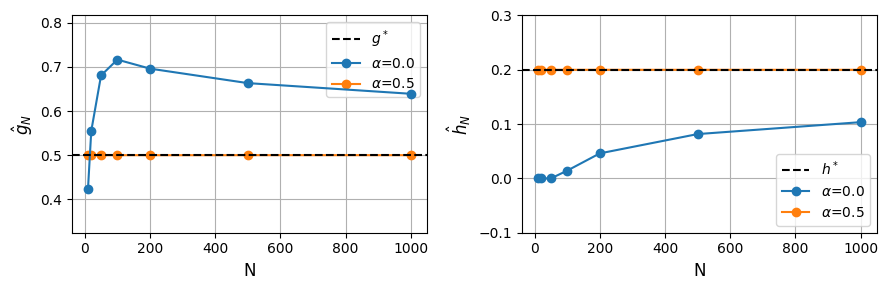

In [13]:
N_set = [10, 20, 50, 100, 200, 500, 1000]
mu1, sigma1, g1, h1 = 0.0, 1.0, 0.5, 0.2
res2d = expr_wellspecified_2d(mu1, sigma1, g1, h1, N_set, ver='sc')

(1e-06, 5)

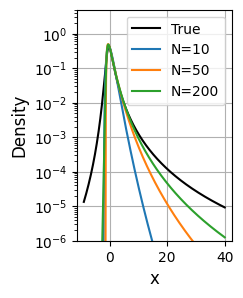

In [14]:
true_theta = np.array([mu1, sigma1, g1, h1])
x = np.linspace(-9, 40, 1001)

plt.figure(figsize=(2,3))
x, pdf = plot_tukey_pdf(x, true_theta, color='k', text='True')
for N_idx in [0,2,4]:
    theta = np.array([mu1, sigma1, g1, h1])
    theta[2:] = res2d['param_uncorrected_set'][N_idx]
    plot_tukey_pdf(x, theta, text=f'N={N_set[N_idx]}')

plt.xlabel("x", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.yscale('log')
plt.grid()
plt.ylim(1e-6, 5)
# plt.title(f"PDF of Tukey g-and-h (N={N})")
# plt.savefig(f'./fig_tukey_finitebias.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [15]:

def plot_res(res, offset=0.1, offset2=0, tidx=None):
    param_uncorrected_set = res['param_uncorrected_set']
    param_corrected_a0_5 = res['param_corrected_a0_5']
    N_set = res['N_set']
    param = res['param']

    dim = len(param)
    if dim == 4:
        labels = [r'$\mu^*$', r'$\sigma^*$', r'$g^*$', r'$h^*$']
        ylabels = [r'$\hat{\mu}_N$', r'$\hat{\sigma}_N$', r'$\hat{g}_N$', r'$\hat{h}_N$']
    else:
        labels = [r'$g^*$', r'$h^*$']
        ylabels = [r'$\hat{g}_N$', r'$\hat{h}_N$']
        
    plt.figure(figsize=(3*(dim+1)+offset2,3))
    for k in range(dim):
        plt.subplot(1,dim,k+1)
        plt.axhline([param[k]], color='k', ls='--', label=labels[k], zorder=20)
        plt.plot(N_set[:tidx], param_uncorrected_set[:tidx,k], label=r'$\alpha$=0.0', marker='o', zorder=10)
        plt.plot(N_set[:tidx], param_corrected_a0_5[:tidx,k], label=r'$\alpha$=0.5', marker='o', zorder=3)
        plt.grid()
        plt.xlabel(f'N', fontsize=12)
        plt.ylabel(ylabels[k], fontsize=12)

        minval = np.min([param[k], np.min(param_uncorrected_set[:tidx,k]), np.min(param_corrected_a0_5[:tidx,k])])
        maxval = np.max([param[k], np.max(param_uncorrected_set[:tidx,k]), np.max(param_corrected_a0_5[:tidx,k])])
        plt.ylim(minval-offset, maxval+offset)
        plt.legend()
    plt.tight_layout()

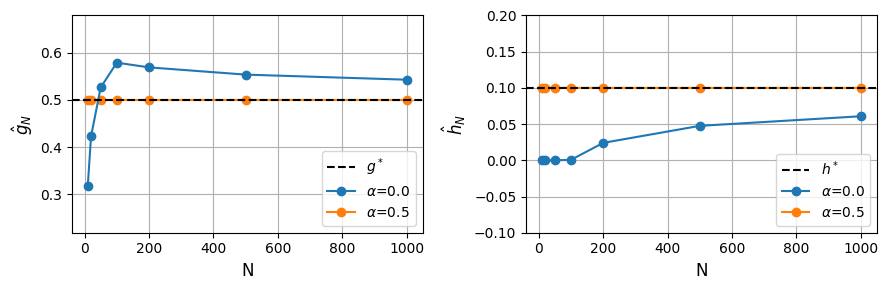

In [17]:
sample_size_set = [10, 20, 50, 100, 200, 500, 1000]
true_theta = np.array([0., 1., 0.5, 0.1])
res_2d = expr_wellspecified_2d(true_theta[0], true_theta[1], true_theta[2], true_theta[3], sample_size_set, ver='sc')

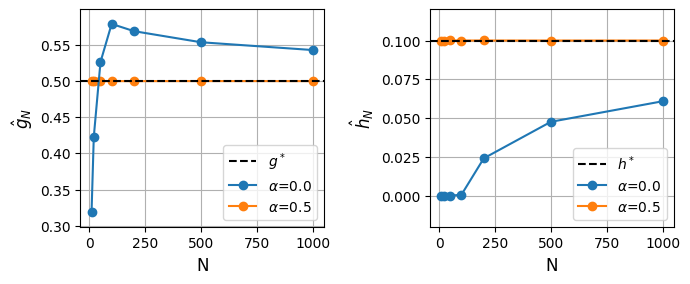

In [18]:
plot_res(res_2d, offset=0.02, offset2=-2)
# plt.savefig(f'./fig_tukey_wellspecified.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [19]:
res_2d['param_uncorrected_set']

array([[0.31856132, 0.        ],
       [0.42271221, 0.        ],
       [0.52641886, 0.        ],
       [0.5790869 , 0.00065297],
       [0.56905441, 0.02409796],
       [0.5537225 , 0.04761145],
       [0.54293754, 0.06085491]])

# Stochastic optimization

In [20]:
def sqW2loss(theta, target_sample, alpha, Z1_sorted=None, Z2_sorted=None):
    N = len(target_sample)
    target_sample_sorted = np.sort(target_sample)

    if Z1_sorted is None:
        Z1_sorted = np.sort(np.random.normal(0, 1, N))
    gen_sample1_sorted, sample1_grad = tukey_gh_sample_with_grads(sample_size, mu=theta[0], sigma=theta[1], g=theta[2], h=theta[3], Z=Z1_sorted)

    if alpha == 0:
        return np.mean((target_sample_sorted - gen_sample1_sorted)**2)
    else:
        if Z2_sorted is None:
            Z2_sorted = np.sort(np.random.normal(0, 1, N))
        gen_sample2_sorted, sample2_grad = tukey_gh_sample_with_grads(sample_size, mu=theta[0], sigma=theta[1], g=theta[2], h=theta[3], Z=Z2_sorted)
    
    return np.mean((target_sample_sorted - gen_sample1_sorted)**2) - alpha*np.mean((gen_sample2_sorted - gen_sample1_sorted)**2)

def stochastic_gradient_sqW2loss(theta, target_sample, alpha, Z1_sorted=None, Z2_sorted=None):
    N = len(target_sample)
    target_sample_sorted = np.sort(target_sample)

    if Z1_sorted is None:
        Z1_sorted = np.sort(np.random.normal(0, 1, N))
    gen_sample1_sorted, sample1_grad = tukey_gh_sample_with_grads(sample_size, mu=theta[0], sigma=theta[1], g=theta[2], h=theta[3], Z=Z1_sorted)
    grad1 = 2 * np.mean((gen_sample1_sorted - target_sample_sorted)[np.newaxis,:]*sample1_grad, axis=1)

    if alpha == 0:
        return grad1
    else:
        if Z2_sorted is None:
            Z2_sorted = np.sort(np.random.normal(0, 1, N))
        gen_sample2_sorted, sample2_grad = tukey_gh_sample_with_grads(sample_size, mu=theta[0], sigma=theta[1], g=theta[2], h=theta[3], Z=Z2_sorted)
        grad2 = 2 * np.mean((gen_sample1_sorted - gen_sample2_sorted)[np.newaxis,:]*(sample1_grad - sample2_grad), axis=1)
    
    return grad1 - alpha*grad2

def robbins_monro_steps(i, eta0, gamma):
    return eta0 / (1 + gamma*float(i))

def sgd_empirical_sqW2loss(theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims = [], clipval=np.inf):
    for idx in fixdims:
        theta0[idx] = true_theta[idx]
    theta = np.array(theta0)
    theta_trj = []
    theta_trj.append(np.array(theta))
    grad_trj = []
    for i in range(n_iter):
        # Target sample
        Z = np.random.normal(0, 1, sample_size)
        target_sample = tukey_gh_sample(sample_size, mu=true_theta[0], sigma=true_theta[1], g=true_theta[2], h=true_theta[3], Z=Z)
        
        # Generator sample with current theta
        grad = stochastic_gradient_sqW2loss(theta, target_sample, alpha)

        # Clip by global norm
        grad = clip_grad_by_norm(grad, fixdims, max_norm=clipval)
        
        # --- Check for NaN/Inf before applying the update ---
        # if not np.all(np.isfinite(grad)):
        #     # print(f"[Warning] Iter {i}: gradient has NaN/Inf, skipping update.")
        #     grad_trj.append(np.full_like(theta, np.nan))
        #     theta_trj.append(np.copy(theta))
        #     continue  # skip this step entirely
        
        stepsize = robbins_monro_steps(i, eta0, gamma)
        theta -= stepsize * grad
        for idx in fixdims:
            theta[idx] = true_theta[idx]
        # print(grad, theta)
        if theta[1] < 0:
            theta[1] = 0
        if theta[3] < 0:
            theta[3] = 0
        if theta[3] > 0.499:
            theta[3] = 0.499
        theta_trj.append(np.array(theta))
        grad_trj.append(grad)
    theta_trj = np.array(theta_trj)
    grad_trj = np.array(grad_trj)
    return theta_trj, grad_trj


In [21]:
def clip_grad_by_norm(grad, fixdims, max_norm=1.0, eps=1e-12):
    norm = np.linalg.norm(np.delete(grad, fixdims))
    if norm > max_norm:
        grad *= (max_norm / (norm + eps))
    return grad

In [22]:
np.random.seed(0)
true_theta = np.array([0., 1., 0.5, 0.1])
theta0 = np.array([0., 1., 0.3, 0.0])
n_iter, eta0, gamma = 200000, 0.001, 0.001
sample_size_set = [10, 20, 50, 100, 200, 500, 1000]# [2, 5, 10, 20, 50, 100, 1000]#[50, 100, 200, 500, 1000]
alpha = 0.0

theta_trj_set = {}
grad_trj_set = {}
theta_emp_sol_set = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_trj, grad_trj = sgd_empirical_sqW2loss(theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims=[0,1], clipval=3000)
    theta_trj_set[str(sample_size)] = theta_trj
    grad_trj_set[str(sample_size)] = grad_trj

0 10
1 20
2 50
3 100
4 200
5 500
6 1000


In [23]:
np.random.seed(0)
true_theta = np.array([0., 1., 0.5, 0.1])
theta0 = np.array([0., 1., 0.3, 0.0])
n_iter, eta0, gamma = 200000, 0.001, 0.001
sample_size_set = [10, 20, 50, 100, 200, 500, 1000]# [2, 5, 10, 20, 50, 100, 1000]#[50, 100, 200, 500, 1000]
alpha = 0.5

theta_debias_trj_set = {}
grad_debias_trj_set = {}
for i, sample_size in enumerate(sample_size_set):
    print(i, sample_size)
    theta_debias_trj, grad_debias_trj = sgd_empirical_sqW2loss(theta0, true_theta, sample_size, alpha, n_iter, eta0, gamma, fixdims=[0,1], clipval=3000)
    theta_debias_trj_set[str(sample_size)] = theta_debias_trj
    grad_debias_trj_set[str(sample_size)] = grad_debias_trj

0 10
1 20
2 50
3 100
4 200
5 500
6 1000


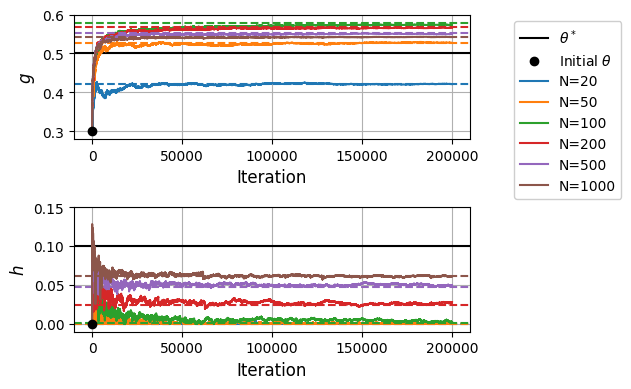

In [24]:
sample_size_set = [20, 50, 100, 200, 500, 1000]
plt.figure(figsize=(7,4))
# figidx = [0,1,2,3]
figidx = [2,3]
for k,i in enumerate(figidx):
    plt.subplot(len(figidx),1,k+1)
    plt.axhline(true_theta[i], color='k', linestyle='-', label=fr'$\theta^*$')
    plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
    for j, sample_size in enumerate(sample_size_set):
        # if sample_size in [10,20,50,200,500,1000]:
        #     continue
        theta_trj = theta_trj_set[str(sample_size)]
        idx = res_2d['N_set'].index(sample_size)
        plt.plot(theta_trj[:,i], label=fr'N={sample_size}')
        plt.axhline(res_2d['param_uncorrected_set'][idx,k], color=plt.gca().lines[-1].get_color(), linestyle='--')
    plt.grid()
    plt.xticks([0, 50000, 100000, 150000, 200000])
    if k==0:
        plt.ylim([0.28,0.6])
        plt.ylabel(fr'$g$', fontsize=12)
    elif k==1:
        plt.ylim([-0.01,0.15])
        plt.ylabel(fr'$h$', fontsize=12)
    
    plt.xlabel('Iteration', fontsize=12)
    if k == 0:
        plt.legend(loc='upper right', framealpha=0.95, bbox_to_anchor=(1.4, 1.0))
plt.tight_layout()
# plt.savefig(f'./fig_sgd_tukey.pdf', format='pdf', bbox_inches="tight", dpi=300)

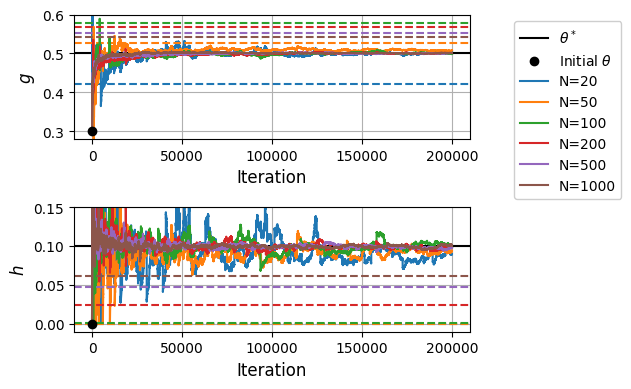

In [25]:
sample_size_set = [20, 50, 100, 200, 500, 1000]
plt.figure(figsize=(7,4))
# figidx = [0,1,2,3]
figidx = [2,3]
for k,i in enumerate(figidx):
    plt.subplot(len(figidx),1,k+1)
    plt.axhline(true_theta[i], color='k', linestyle='-', label=fr'$\theta^*$')
    plt.scatter(0, theta0[i], marker='o', c='k', label=fr'Initial $\theta$', zorder=100)
    for j, sample_size in enumerate(sample_size_set):
        # if sample_size in [100]:
        #     continue
        theta_debias_trj = theta_debias_trj_set[str(sample_size)]
        idx = res_2d['N_set'].index(sample_size)
        plt.plot(theta_debias_trj[:,i], label=fr'N={sample_size}')
        plt.axhline(res_2d['param_uncorrected_set'][idx,k], color=plt.gca().lines[-1].get_color(), linestyle='--')
    plt.grid()
    plt.xticks([0, 50000, 100000, 150000, 200000])
    if k==0:
        plt.ylim([0.28,0.6])
        plt.ylabel(fr'$g$', fontsize=12)
    elif k==1:
        plt.ylim([-0.01,0.15])
        plt.ylabel(fr'$h$', fontsize=12)
    
    plt.xlabel('Iteration', fontsize=12)
    if k == 0:
        plt.legend(loc='upper right', framealpha=0.95, bbox_to_anchor=(1.4, 1.0))
plt.tight_layout()
# plt.savefig(f'./fig_sgd_tukey_bias_corrected.pdf', format='pdf', bbox_inches="tight", dpi=300)